# Employee Productivity Prediction


Rosie Navarro 

September 2026

## Purpose: 
The goal of this project is to identify factors that influence employee productivity and build a predictive model that estimates productivity based on workplace and employee characteristics. 

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


The first step of this project is to import the data that is being used. From there we can see the variables that are going to be used during the analysis. The data was obtained from a Kaggle dataset: https://www.kaggle.com/datasets/mexwell/employee-performance-and-productivity-data?resource=download 

In [3]:
productivity = pd.read_csv('/Users/rosienavarro/Data_Science/Productivity.csv')

productivity.head(10)

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False
5,6,IT,Male,43,Manager,2016-08-14 08:03:05.556036,8,High School,3,7800.0,46,31,8,0,100,15,95,0,2.77,False
6,7,IT,Male,37,Technician,2023-08-28 08:03:05.556036,1,Bachelor,5,5250.0,55,20,29,2,0,16,27,0,4.46,False
7,8,Engineering,Female,55,Engineer,2014-10-27 08:03:05.556036,9,Bachelor,2,7200.0,42,46,7,8,100,7,64,0,2.09,False
8,9,Marketing,Female,55,Technician,2023-06-29 08:03:05.556036,1,High School,2,4200.0,51,23,21,14,0,1,0,1,1.44,False
9,10,Engineering,Female,45,Consultant,2016-12-23 08:03:05.556036,7,Bachelor,1,6050.0,41,33,2,6,75,4,53,2,2.93,False


From this dataset, there is a total of 20 variables. 

The following is what each variable means: 
- Employee_ID: Unique identifier for each employee.
- Department: The department in which the employee works (e.g., Sales, HR, IT).
- Gender: Gender of the employee (Male, Female, Other).
- Age: Employee's age (between 22 and 60).
- Job_Title: The role held by the employee (e.g., Manager, Analyst, Developer).
- Hire_Date: The date the employee was hired.
- Years_At_Company: The number of years the employee has been working for the company.
- Education_Level: Highest educational qualification (High School, Bachelor, Master, PhD).
- Performance_Score: Employee's performance rating (1 to 5 scale).
- Monthly_Salary: The employee's monthly salary in USD, correlated with job title and performance score.
- Work_Hours_Per_Week: Number of hours worked per week.
- Projects_Handled: Total number of projects handled by the employee.
- Overtime_Hours: Total overtime hours worked in the last year.
- Sick_Days: Number of sick days taken by the employee.
- Remote_Work_Frequency: Percentage of time worked remotely (0%, 25%, 50%, 75%, 100%).
- Team_Size: Number of people in the employee's team.
- Training_Hours: Number of hours spent in training.
- Promotions: Number of promotions received during their tenure.
- Employee_Satisfaction_Score: Employee satisfaction rating (1.0 to 5.0 scale).
- Resigned: Boolean value indicating if the employee has resigned.


## Exploratory Data Analysis (EDA): 

An important step is to make sure that there is no missing values in the dataset. This will be done using the null(). If there is a missing value for any of the variables a number will show up next to it. 

In [4]:
productivity.isnull().sum()

Employee_ID                    0
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Hire_Date                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
Resigned                       0
dtype: int64

There are no missing value in the dataset. Info also allows us to see if there are any null values, which can be compared to the number of rows used. Additionally, info allows us to see the data type for each variable. 

There is a total of 5 string variables, 12 integers, 2 floats, and 1 boolean. 

In [5]:
productivity.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  str    
 2   Gender                       100000 non-null  str    
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  str    
 5   Hire_Date                    100000 non-null  str    
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  str    
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  Sick_Days  

One thing to keep in mind, is the company has different departments, each one can have varying degrees of productivity and how productivity is measured. 

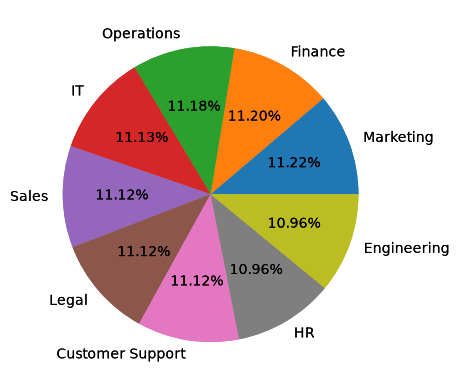

In [12]:
productivity.Department.value_counts().plot.pie(autopct='%.2f%%')

plt.show()

The number of employees in each department is evenly distributed. For the most part each department contains 10.96% to 11.22% of the total employees. 

There is a total of 9 departments. Each department can have different performance scores. The mean performance score for each department will be found, it will range from 0 to 5. 

In [17]:
department_product = (
    productivity.groupby("Department")["Performance_Score"]
                .mean()
                .sort_values(ascending=False))

department_product

Department
Engineering         3.020263
Operations          3.006797
IT                  3.000000
HR                  2.997354
Customer Support    2.997121
Sales               2.994336
Legal               2.981741
Finance             2.981161
Marketing           2.980653
Name: Performance_Score, dtype: float64

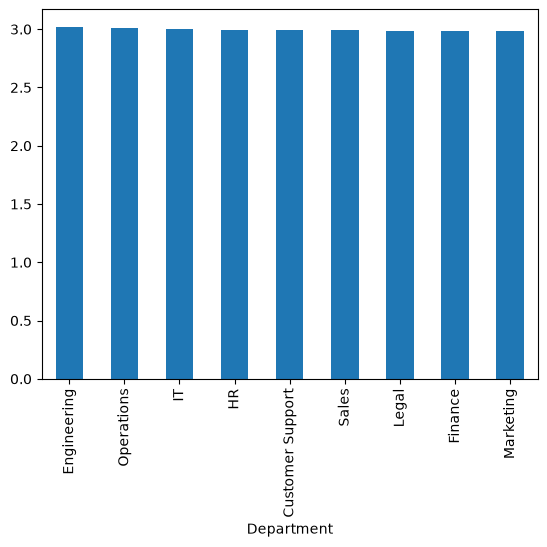

In [16]:
department_product.plot(kind="bar")

plt.show()

All of the departments have similar performance scores. The scores range from 3.02 to 2.98. The bar plot show those results. This shows us that performance does not depend on the department.  

This can also be done with Employee Satisfaction. 

In [23]:
department_sat = (
    productivity.groupby("Department")["Employee_Satisfaction_Score"]
                .mean()
                .sort_values(ascending=False))

department_product

Department
Engineering         3.020263
Operations          3.006797
IT                  3.000000
HR                  2.997354
Customer Support    2.997121
Sales               2.994336
Legal               2.981741
Finance             2.981161
Marketing           2.980653
Name: Performance_Score, dtype: float64

The Employee Satisfication Score also shows us similar results. Satisfaction score does not depend on department. 

Correlation matrix can be made with all of the variables to see if there is correlation between the variables. If the value is closer to 0, this means that the relationship between the variables is weak. If the value is closer to -1 or 1 this means the relationship between the variables is stronger. 

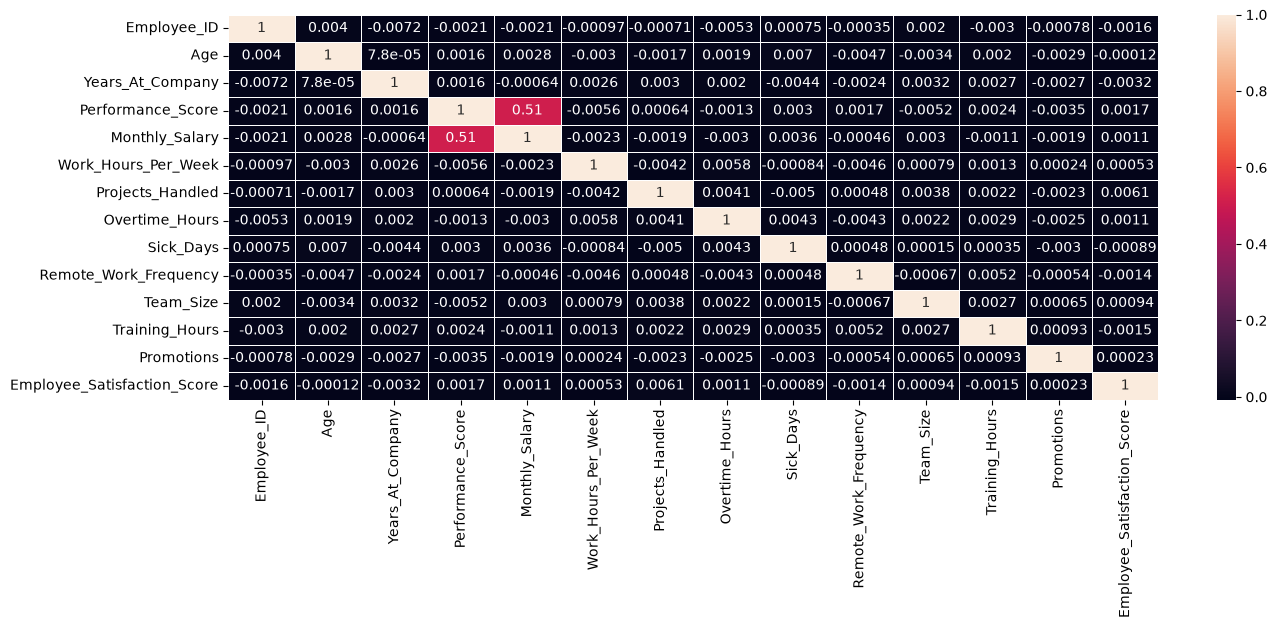

In [37]:
corrMatrix = productivity.select_dtypes(include="number").corr()

fig, ax = plt.subplots(figsize=(15,5))
sns.heatmap(corrMatrix, annot=True, linewidth=.5, ax=ax)

plt.show()

There is one relationship that stands out in the correlation matrix. There is a relationship between Performance score and Monthly Salary. It has a correlation coefficient of 0.51, indicating that there is a moderately strong positive relationship. All of the other relationshps have a very weak relationship. 

A scatter plot can be made to see the relationship between Monthly Salary and Performance Score. 

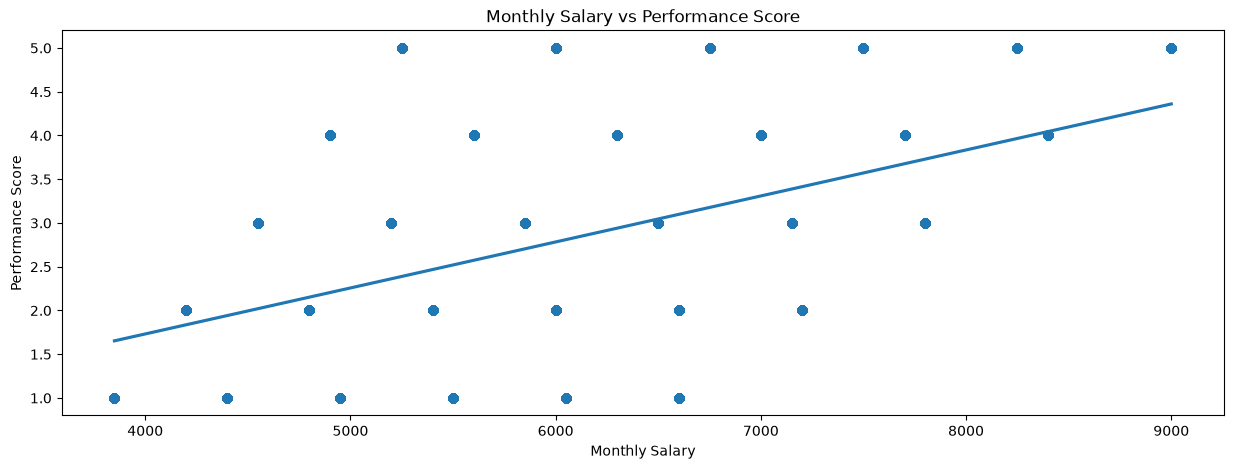

In [38]:
fig, ax = plt.subplots(figsize=(15,5))
sns.regplot(data=productivity, x="Monthly_Salary", y="Performance_Score")

plt.title("Monthly Salary vs Performance Score")
plt.ylabel("Performance Score")
plt.xlabel("Monthly Salary")
plt.show()

In [39]:
productivity["Monthly_Salary"].nunique()

28

The plot looks arranged in a specific order. Since there are only 28 unique Monthly Salaries recorded this can be the reason that the points look arranged in a line. There is a limit in the y-axis, the scores range between 1 to 5. On the other hand, there are only 28 recorded monthly salaries. It is normal that there are multiple points that overlap. 

The regression line shows that there is a positive relationship between monthly salaries and Performance score. 

## Model

In [41]:
X = productivity[["Monthly_Salary"]]
y = productivity["Performance_Score"]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Monthly_Salary']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.3567
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [45]:
y_pred = model1.predict(X_test)

In [51]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(r2)
print(rmse)
print(mae)

0.26653832325588167
1.2126733677135126
1.0081581034356053
